# 투구 제구 성공 확률 예측 - 탐색용 노트북

이 노트북은 `train_ensemble.py`의 로직을 셀 단위로 쪼개서
- 데이터가 예상한 형태인지
- 트랙맨 매칭률이 실제로 얼마나 나오는지
- 모델 하나만 먼저 돌렸을 때 Brier가 어느 정도인지
- 보정(calibration) 전/후 점수 차이가 실제로 있는지

를 눈으로 확인하기 위한 용도입니다. 여기서 검증이 끝나면
동일 디렉토리의 `train_ensemble.py` / `script.py`로 옮겨 제출 규격에 맞춥니다.

> 이 파일과 `train_ensemble.py`는 같은 폴더에 있어야 아래 import가 동작합니다.

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

sys.path.append(os.getcwd())
from train_ensemble import (
    ID_COL, TARGET_COL, CAT_COLS,
    build_trackman_pitcher_prior, attach_trackman_prior, build_features,
    train_lgb, train_xgb, train_cat,
)

DATA_DIR = "../open/data"  # train.csv, trackman_history.csv 위치로 수정

## 1. 데이터 로드 & 기본 확인

가장 먼저 확인할 것:
- 행/컬럼 수가 설명서(1,475,092행 x 49컬럼)와 일치하는지
- `control_success` 비율(r)이 어느 정도인지 → 베이스라인 Brier(r(1-r))를 직접 계산해볼 수 있음

In [2]:
train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"), encoding="utf-8-sig")
print(train.shape)
train.head()

(1475092, 49)


,row_id,season,game_month,game_dayofweek,inning,top_bottom,game_type,balls_before,strikes_before,outs_before,...,asof_pitcher_prev3_game_middle_rate,asof_pitcher_prev5_game_middle_rate,asof_batter_n,asof_batter_success_rate,asof_batter_middle_rate,asof_pitcher_pitchmix_n,asof_pitcher_fastball_rate,asof_pitcher_breaking_rate,asof_pitcher_offspeed_rate,control_success
0,TRAIN_0000001,2019,3,5,1,T,R,0,0,0,...,NaN,NaN,0,NaN,NaN,0,NaN,NaN,NaN,0
1,TRAIN_0000002,2019,3,5,1,T,R,0,0,0,...,NaN,NaN,0,NaN,NaN,1,1.0,0.0,0.0,0
2,TRAIN_0000003,2019,3,5,1,T,R,1,0,0,...,NaN,NaN,1,0.0,0.0,2,1.0,0.0,0.0,0
3,TRAIN_0000004,2019,3,5,1,T,R,0,0,2,...,NaN,NaN,0,NaN,NaN,3,1.0,0.0,0.0,1
4,TRAIN_0000005,2019,3,5,1,T,R,0,1,2,...,NaN,NaN,1,1.0,0.0,4,1.0,0.0,0.0,1


In [3]:
train['pitcher_id'].describe()

count    1.475092e+06
mean     2.326594e+04
std      8.003636e+02
min      2.070000e+04
25%      2.265100e+04
50%      2.347800e+04
75%      2.388000e+04
max      2.463300e+04
Name: pitcher_id, dtype: float64

In [4]:
trackman_history = pd.read_csv(os.path.join(DATA_DIR, "trackman_history.csv"), encoding="utf-8-sig")
# print(trackman_history.shape)
trackman_history['pitcher_trackman_id'].describe()

count    1.793078e+06
mean     1.463249e+05
std      7.253059e+05
min      5.000800e+04
25%      6.126800e+04
50%      6.660900e+04
75%      7.042500e+04
max      7.177516e+07
Name: pitcher_trackman_id, dtype: float64

In [5]:
r = train[TARGET_COL].mean()
baseline_brier = r * (1 - r)
print(f"제구 성공률 r = {r:.4f}")
print(f"기준(무정보) Brier = {baseline_brier:.5f}  <- 이거보다 낮게 만들어야 Score>0")

제구 성공률 r = 0.5238
기준(무정보) Brier = 0.24944  <- 이거보다 낮게 만들어야 Score>0


In [6]:
train.isna().mean().sort_values(ascending=False).head(20)  # 컬럼별 결측률 확인

asof_pitcher_prev5_game_success_rate    0.019785
asof_pitcher_prev3_game_middle_rate     0.019785
asof_pitcher_prev1_game_success_rate    0.019785
asof_pitcher_prev3_game_success_rate    0.019785
asof_pitcher_prev1_game_middle_rate     0.019785
asof_pitcher_prev5_game_middle_rate     0.019785
asof_batter_middle_rate                 0.000563
asof_batter_success_rate                0.000563
asof_pitcher_success_rate               0.000537
asof_pitcher_fastball_rate              0.000537
asof_pitcher_breaking_rate              0.000537
asof_pitcher_offspeed_rate              0.000537
asof_pitcher_strike_rate                0.000537
asof_pitcher_ball_rate                  0.000537
asof_pitcher_middle_rate                0.000537
asof_pitcher_reverse_rate               0.000537
batter_team_id                          0.000000
pitcher_team_id                         0.000000
asof_pitcher_n                          0.000000
row_id                                  0.000000
dtype: float64

## 2. 트랙맨 매칭률 확인 (중요)

`pitcher_id`와 `pitcher_trackman_id`가 같은 익명화 공간인지 실제로 확인.
매칭률이 너무 낮으면(예: <5%) 트랙맨 prior는 이번 라운드에서는 빼고
`asof_*` 컬럼만으로 먼저 베이스라인을 잡는 게 낫습니다.

In [7]:
trackman_path = os.path.join(DATA_DIR, "trackman_history.csv")
prior_table = None
if os.path.exists(trackman_path):
    prior_table = build_trackman_pitcher_prior(trackman_path)
    print(prior_table.shape)
    display(prior_table.head())

    tmp = train[["pitcher_id"]].merge(prior_table[["pitcher_id"]].drop_duplicates(),
                                        on="pitcher_id", how="left", indicator=True)
    match_rate = (tmp["_merge"] == "both").mean()
    print(f"train 기준 pitcher_id 매칭률: {match_rate:.1%}")
else:
    print("trackman_history.csv가 없습니다. asof_* 컬럼만으로 진행합니다.")

(906, 11)


,pitcher_id,tm_n,tm_rel_speed_mean,tm_spin_rate_mean,tm_ivb_mean,tm_hb_mean,tm_extension_mean,tm_mix_breaking,tm_mix_fastball,tm_mix_offspeed,tm_mix_other
0,50008,30,133.413767,2215.786333,27.113480,-8.038093,1.474019,0.300000,0.700000,0.000000,0.000000
1,50010,986,131.357377,2118.265219,33.968337,13.478821,1.789900,0.365112,0.530426,0.098377,0.006085
2,50030,7449,137.945706,2025.213418,16.779461,20.716356,1.878885,0.149416,0.594845,0.250906,0.004833
3,50036,2246,141.768521,2240.995336,2.657223,33.136029,1.778326,0.178985,0.753339,0.062333,0.005343
4,50094,301,133.295620,2081.299667,34.780670,4.029097,1.787843,0.265781,0.644518,0.086379,0.003322


train 기준 pitcher_id 매칭률: 0.0%


## 3. 피처 엔지니어링 확인

`build_features`가 만든 컬럼 목록과, 카테고리/수치형이 의도대로 처리됐는지 확인.
매칭률이 낮았다면 아래에서 `trackman_prior=None`으로 바꿔서 진행하세요.

In [8]:
USE_TRACKMAN = False  # 위에서 매칭률 확인 후 False로 바꿔도 됨

train_feat, feat_cols = build_features(
    train, prior_table if USE_TRACKMAN else None
)
cat_features = [c for c in CAT_COLS if c in feat_cols]

print(f"피처 개수: {len(feat_cols)}")
print(f"범주형: {cat_features}")
train_feat[feat_cols].dtypes.value_counts()

피처 개수: 75
범주형: ['top_bottom', 'game_type', 'base_state', 'pitcher_hand', 'batter_hand', 'hand_matchup']


int64       26
float64     24
int8        19
category     2
category     1
category     1
category     1
category     1
Name: count, dtype: int64

## 4. 빠른 베이스라인: LightGBM 1개만 먼저 (전체 앙상블 전에 감 잡기)

풀 데이터로 5-fold 다 돌리면 시간이 걸리니, 먼저 **일부 샘플 + 폴드 축소**로
파이프라인이 끝까지 도는지, Brier가 합리적인지부터 빠르게 확인합니다.

In [9]:
SAMPLE_N = 200_000  # 우선 20만 행 정도로 빠르게 확인 (전체 147만행은 이후)

sample_idx = train_feat.sample(n=min(SAMPLE_N, len(train_feat)), random_state=42).index
X_small = train_feat.loc[sample_idx, feat_cols]
y_small = train_feat.loc[sample_idx, TARGET_COL].values

# train_lgb 내부는 5-fold 기본값 -> 빠른 확인 목적이면 함수 내부의 n_folds를 2~3으로
# 잠깐 바꿔 쓰거나, 아래처럼 그대로 5-fold 돌려도 20만행이면 수 분 내로 끝남
lgb_models, lgb_oof = train_lgb(X_small, y_small, X_small, cat_features)
lgb_brier_score = brier_score_loss(y_small, lgb_oof)
print(f"LightGBM 단일모델 OOF Brier (표본 {SAMPLE_N}행): {lgb_brier_score:.5f}")
print(f"참고 - 기준 Brier: {baseline_brier:.5f}")
print(f"기준 대비 개선량 : {100* (baseline_brier - lgb_brier_score)/baseline_brier:.2f}%")
print(f"점수 : {max(0, 100000 * (1 - lgb_brier_score/baseline_brier)):.5f}")

  [LGB fold 0] brier=0.24538
  [LGB fold 1] brier=0.24556
  [LGB fold 2] brier=0.24477
  [LGB fold 3] brier=0.24560
  [LGB fold 4] brier=0.24553
LightGBM 단일모델 OOF Brier (표본 200000행): 0.24537
참고 - 기준 Brier: 0.24944
기준 대비 개선량 : 1.63%
점수 : 1631.19443


## Feature Importance 확인 (4번 다음, 5번 보정 이전)

방금 학습한 `lgb_models`(5-fold 각각의 LightGBM 모델)에서
**추가 학습 없이** feature importance를 뽑아 확인합니다.

- `importance_type="gain"`을 씁니다: 이 피처로 분기했을 때 손실이 얼마나 줄었는지 누적한 값이라,
  단순히 "몇 번 분기에 쓰였는지"(split)보다 실제 기여도를 더 잘 반영합니다.
- 5개 폴드 모델의 importance를 평균 내서, 특정 폴드에서만 튄 값이 아닌지 확인합니다.

확인할 포인트:
1. **특정 피처 하나가 압도적으로(예: 50% 이상) 독식하고 있는가?**
   → 그렇다면 리크(현재/미래 정보가 새어 들어간 피처)일 가능성을 의심해봐야 합니다.
2. **importance가 여러 피처에 고르게 퍼져 있는가?**
   → 그렇다면 지금 개선폭이 작은 건 버그가 아니라 "이 문제 자체의 한계"에 가깝다는 뜻입니다.
3. **범주형 컬럼(`base_state`, `game_type`, `top_bottom` 등)이 잘 쓰이고 있는가, 아니면 거의 안 쓰이는가?**
   → 안 쓰이고 있다면 인코딩 방식을 재검토할 여지가 있습니다.

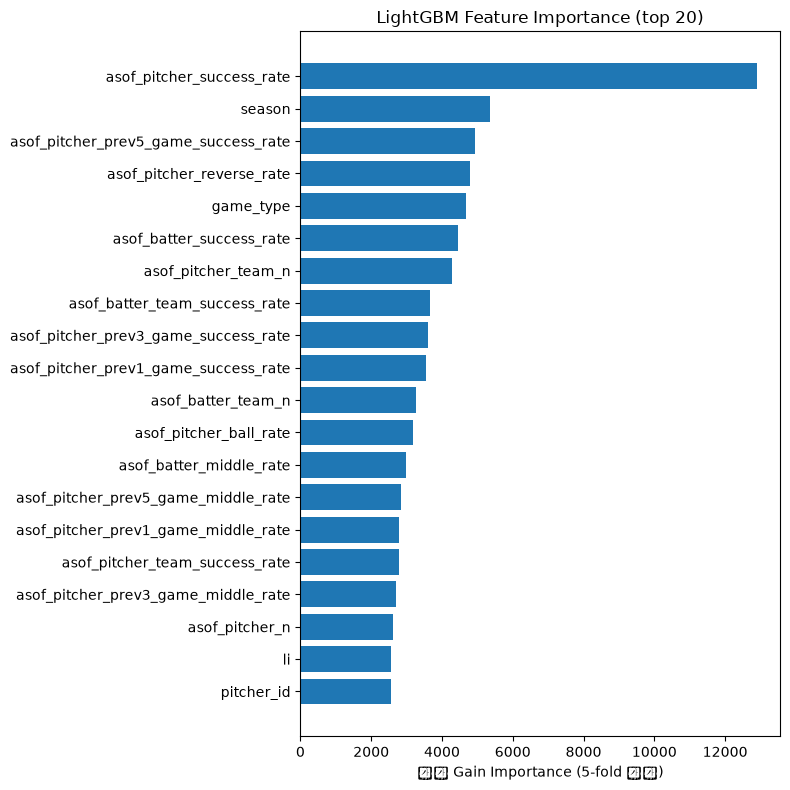

1위 피처 비중: 11.0%  (50% 넘으면 리크 의심)


,mean_gain,share_pct
asof_pitcher_success_rate,12905.127565,10.976363
season,5364.481206,4.562721
asof_pitcher_prev5_game_success_rate,4935.531153,4.197880
asof_pitcher_reverse_rate,4783.346796,4.068441
game_type,4688.413817,3.987697
asof_batter_success_rate,4453.196469,3.787634
asof_pitcher_team_n,4275.110210,3.636164
asof_batter_team_success_rate,3660.063463,3.113041
asof_pitcher_prev3_game_success_rate,3612.372605,3.072477
asof_pitcher_prev1_game_success_rate,3551.051815,3.020321


In [10]:
imp_df = pd.DataFrame({
    f"fold{i}": m.feature_importance(importance_type="gain")
    for i, m in enumerate(lgb_models)
}, index=feat_cols)
imp_df["mean_gain"] = imp_df[[c for c in imp_df.columns if c.startswith("fold")]].mean(axis=1)
imp_df = imp_df.sort_values("mean_gain", ascending=False)

# 전체 대비 비중(%)도 같이 확인 -> 특정 피처 독식 여부 판단용
imp_df["share_pct"] = imp_df["mean_gain"] / imp_df["mean_gain"].sum() * 100

top_n = 20
top = imp_df.head(top_n).iloc[::-1]  # 그래프에서 위쪽에 1등이 오도록 뒤집기

plt.figure(figsize=(8, 8))
plt.barh(top.index, top["mean_gain"])
plt.xlabel("평균 Gain Importance (5-fold 평균)")
plt.title(f"LightGBM Feature Importance (top {top_n})")
plt.tight_layout()
plt.show()

print(f"1위 피처 비중: {imp_df.iloc[0]['share_pct']:.1f}%  (50% 넘으면 리크 의심)")
imp_df[["mean_gain", "share_pct"]].head(20)

## 5. 보정(calibration) 전/후 비교 — 왜 필요한지 눈으로 확인

Reliability diagram(신뢰도 곡선)을 그려서, 모델이 뱉은 확률이
실제 발생 빈도와 얼마나 어긋나는지 확인합니다. 대각선에 가까울수록 잘 보정된 것.

보정 전 Brier: 0.24537
보정 후 Brier: 0.24524


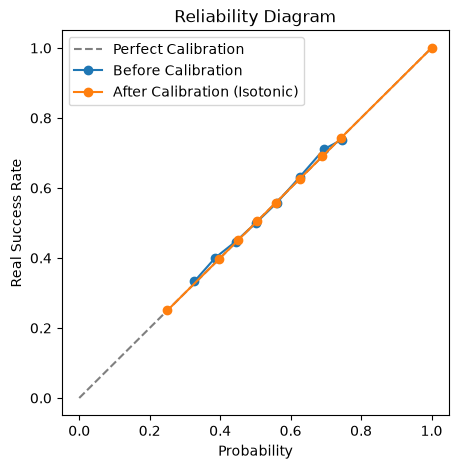

In [11]:
from sklearn.isotonic import IsotonicRegression

iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(lgb_oof, y_small)
lgb_oof_cal = iso.predict(lgb_oof)

print(f"보정 전 Brier: {brier_score_loss(y_small, lgb_oof):.5f}")
print(f"보정 후 Brier: {brier_score_loss(y_small, lgb_oof_cal):.5f}")

frac_pos_raw, mean_pred_raw = calibration_curve(y_small, lgb_oof, n_bins=15)
frac_pos_cal, mean_pred_cal = calibration_curve(y_small, lgb_oof_cal, n_bins=15)

plt.figure(figsize=(5,5))
plt.plot([0,1],[0,1], linestyle="--", color="gray", label="Perfect Calibration")
plt.plot(mean_pred_raw, frac_pos_raw, marker="o", label="Before Calibration")
plt.plot(mean_pred_cal, frac_pos_cal, marker="o", label="After Calibration (Isotonic)")
plt.xlabel("Probability"); plt.ylabel("Real Success Rate")
plt.legend(); plt.title("Reliability Diagram")
plt.show()

## 7. XGBoost / CatBoost 추가 — 같은 조건에서 비교

지금까지는 LightGBM 하나만 봤습니다. 여기서는 **같은 `X_small`, `y_small`(20만 행 샘플),
같은 `cat_features`**를 그대로 넣어서 XGBoost, CatBoost도 학습합니다.
조건을 똑같이 맞춰야 "모델 자체의 차이"만 비교할 수 있습니다.

XGBoost, CatBoost도 5-fold라 LightGBM만큼(수 분) 걸릴 수 있습니다.

In [12]:
xgb_models, xgb_oof = train_xgb(X_small, y_small, cat_features)
print(f"XGBoost 단일모델 OOF Brier (표본 {SAMPLE_N}행): {brier_score_loss(y_small, xgb_oof):.5f}")
print(f"참고 - 기준 Brier: {baseline_brier:.5f}")

  [XGB fold 0] brier=0.24552
  [XGB fold 1] brier=0.24561
  [XGB fold 2] brier=0.24478
  [XGB fold 3] brier=0.24571
  [XGB fold 4] brier=0.24556
XGBoost 단일모델 OOF Brier (표본 200000행): 0.24544
참고 - 기준 Brier: 0.24944


In [13]:
cat_models, cat_oof = train_cat(X_small, y_small, cat_features)
print(f"CatBoost 단일모델 OOF Brier (표본 {SAMPLE_N}행): {brier_score_loss(y_small, cat_oof):.5f}")
print(f"참고 - 기준 Brier: {baseline_brier:.5f}")

  [CAT fold 0] brier=0.24536
  [CAT fold 1] brier=0.24557
  [CAT fold 2] brier=0.24484
  [CAT fold 3] brier=0.24556
  [CAT fold 4] brier=0.24560
CatBoost 단일모델 OOF Brier (표본 200000행): 0.24539
참고 - 기준 Brier: 0.24944


## 8. 세 모델 비교

세 모델의 OOF Brier를 한눈에 비교합니다. 여기서 확인할 것:
- 세 값이 비슷한 수준으로 모여 있다면 → "모델 종류보다 피처 자체의 한계"라는 해석에 힘이 실립니다.
- 한 모델이 눈에 띄게 낮다면 → 나중에 앙상블/스태킹할 때 그 모델 비중을 더 줄 근거가 됩니다.
- 세 모델의 예측값끼리 상관관계가 낮을수록(서로 다른 실수를 한다는 뜻) 앙상블 효과가 커집니다.

In [14]:
compare_df = pd.DataFrame({
    "model": ["LightGBM", "XGBoost", "CatBoost"],
    "oof_brier": [
        brier_score_loss(y_small, lgb_oof),
        brier_score_loss(y_small, xgb_oof),
        brier_score_loss(y_small, cat_oof),
    ],
})
compare_df["vs_baseline_pct"] = (1 - compare_df["oof_brier"] / baseline_brier) * 100
display(compare_df)

# 세 모델 예측값끼리 상관관계 확인 (낮을수록 앙상블 시너지가 큼)
oof_corr = pd.DataFrame({
    "lgb": lgb_oof, "xgb": xgb_oof, "cat": cat_oof,
}).corr()
print("OOF 예측값 상관관계 (낮을수록 앙상블에 유리):")
display(oof_corr)

,model,oof_brier,vs_baseline_pct
0,LightGBM,0.245366,1.631194
1,XGBoost,0.245438,1.602504
2,CatBoost,0.245385,1.623593


OOF 예측값 상관관계 (낮을수록 앙상블에 유리):


,lgb,xgb,cat
lgb,1.000000,0.958053,0.953546
xgb,0.958053,1.000000,0.943477
cat,0.953546,0.943477,1.000000


## 9. 실제 앙상블 효과 확인 — 이론이 아니라 숫자로

상관관계가 0.94~0.96이라 "앙상블 효과가 크진 않을 것"이라는 예상이 맞는지,
**단순 평균 블렌딩**과 **로지스틱 스태킹** 두 가지를 실제로 만들어서 확인합니다.

- **단순 평균**: 세 모델 예측을 그냥 1/3씩 평균 — 구현이 제일 쉽고, 과적합 위험이 없음
- **로지스틱 스태킹**: 세 모델의 (보정된) 예측을 입력으로 받아 최적 가중치를 데이터로부터 학습

`vs_best_single_pct`가 핵심입니다 — 개별 모델 중 가장 잘한 CatBoost(0.245562) 대비
앙상블이 얼마나 더 개선됐는지를 보여줍니다. 이 값이 양수면 앙상블이 실제로 도움이 된다는 뜻이고,
0에 가깝거나 음수면 지금 상관관계가 너무 높아 앙상블 이득이 거의 없다는 뜻입니다.

In [15]:
from sklearn.linear_model import LogisticRegression

# 1) 단순 평균 블렌딩
avg_oof = (lgb_oof + xgb_oof + cat_oof) / 3
avg_brier = brier_score_loss(y_small, avg_oof)

# 2) 로지스틱 스태킹 (각 모델을 먼저 개별 보정한 뒤 스태킹 - 5번 섹션에서 배운 isotonic 재사용)
iso_lgb = IsotonicRegression(out_of_bounds="clip").fit(lgb_oof, y_small)
iso_xgb = IsotonicRegression(out_of_bounds="clip").fit(xgb_oof, y_small)
iso_cat = IsotonicRegression(out_of_bounds="clip").fit(cat_oof, y_small)

lgb_c = iso_lgb.predict(lgb_oof)
xgb_c = iso_xgb.predict(xgb_oof)
cat_c = iso_cat.predict(cat_oof)

meta_X = np.column_stack([lgb_c, xgb_c, cat_c])
meta = LogisticRegression().fit(meta_X, y_small)
stack_oof = meta.predict_proba(meta_X)[:, 1]
stack_brier = brier_score_loss(y_small, stack_oof)

# 결과 정리
result_df = pd.DataFrame({
    "model": ["LightGBM", "XGBoost", "CatBoost", "평균 블렌딩", "로지스틱 스태킹"],
    "oof_brier": [
        brier_score_loss(y_small, lgb_oof),
        brier_score_loss(y_small, xgb_oof),
        brier_score_loss(y_small, cat_oof),
        avg_brier,
        stack_brier,
    ],
})
result_df["vs_baseline_pct"] = (1 - result_df["oof_brier"] / baseline_brier) * 100
result_df["vs_best_single_pct"] = (
    (result_df["oof_brier"].iloc[:3].min() - result_df["oof_brier"])
    / result_df["oof_brier"].iloc[:3].min() * 100
)
display(result_df)

print(f"메타 스태킹 가중치(로지스틱 계수): lgb={meta.coef_[0][0]:.3f}, "
      f"xgb={meta.coef_[0][1]:.3f}, cat={meta.coef_[0][2]:.3f}")

,model,oof_brier,vs_baseline_pct,vs_best_single_pct
0,LightGBM,0.245366,1.631194,0.000000
1,XGBoost,0.245438,1.602504,-0.029166
2,CatBoost,0.245385,1.623593,-0.007728
3,평균 블렌딩,0.245270,1.669735,0.039180
4,로지스틱 스태킹,0.245125,1.728126,0.098539


메타 스태킹 가중치(로지스틱 계수): lgb=1.450, xgb=1.390, cat=1.438


## 6. 여기까지 확인됐다면 다음 단계

- [ ] 트랙맨 매칭률이 쓸만한지 결론 내리기 (3번 셀 결과 기준)
- [ ] LightGBM 단일 모델 OOF Brier가 기준 Brier보다 확실히 낮은지 확인 (4번 셀)
- [ ] 보정 후 Brier가 실제로 개선되는지 확인 (5번 셀) — Score 계산식상 이게 등수에 직결
- [ ] 전체 147만행 + 5-fold + XGBoost/CatBoost까지 확장
- [ ] 여기서 검증된 로직을 `train_ensemble.py`에 그대로 반영 (이미 동일 함수 구조이므로 옮기기 쉬움)
- [ ] 최종적으로 `train_ensemble.py` 실행 → `model/ensemble_bundle.pkl` → `script.py`로 제출 규격 구성

궁금한 부분이나 이상한 결과가 나오면 셀 결과를 공유해주시면 같이 원인을 봐드릴게요.

## GPU 사용 가능 여부 확인 (전체 데이터 학습 전에 먼저 실행)

sklearn(IsotonicRegression, LogisticRegression)은 계산량이 작아 GPU가 필요 없습니다.
느린 건 LightGBM/XGBoost/CatBoost 학습 자체이므로, 이 세 라이브러리가 로컬 GPU를
잡을 수 있는지부터 확인합니다.

In [16]:
import torch
print("torch가 GPU를 인식하는가:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU 이름:", torch.cuda.get_device_name(0))

import subprocess
try:
    print(subprocess.run(["nvidia-smi"], capture_output=True, text=True).stdout[:800])
except FileNotFoundError:
    print("nvidia-smi 명령을 찾을 수 없음 (NVIDIA 드라이버 미설치 또는 PATH 미등록)")

torch가 GPU를 인식하는가: True
GPU 이름: NVIDIA GeForce RTX 4050 Laptop GPU
Thu Aug 13 13:58:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.62                 KMD Version: 610.62        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   53C    P8              3


## 10. 전체 데이터(147만 행)로 확장

지금까지는 `X_small`(20만 행 샘플)로만 확인했습니다. 이제 3번 셀에서 만들어둔
`train_feat`(전체 147만 행에 피처 엔지니어링까지 이미 적용된 데이터)을 그대로 씁니다.
별도로 다시 불러오거나 피처를 다시 만들 필요는 없습니다.

**예상 소요 시간 참고**: 20만 행 기준 XGBoost 33.3초, CatBoost 6분 27초가 걸렸습니다.
전체는 20만 행의 약 7.35배 크기라, 대략 XGBoost는 수 분, CatBoost는 30분~1시간 이상
걸릴 수 있습니다. 그래서 아래 셀을 **모델별로 나눠서** 만들었습니다 —
한 모델이 오래 걸려도 나머지 결과는 이미 확보한 상태로 다음 작업을 이어갈 수 있게 하기 위해서입니다.

각 셀은 실행 시간을 직접 측정해서 출력하도록 했습니다.

In [17]:
import time

X_full = train_feat[feat_cols]
y_full = train_feat[TARGET_COL].values
print(f"전체 학습 데이터: {X_full.shape}")

전체 학습 데이터: (1475092, 75)


In [18]:
t0 = time.time()
lgb_models_full, lgb_oof_full = train_lgb(X_full, y_full, X_full, cat_features)
print(f"[LightGBM] 소요시간: {time.time()-t0:.1f}초")
print(f"[LightGBM] 전체 데이터 OOF Brier: {brier_score_loss(y_full, lgb_oof_full):.5f}")
  
r_full = y_full.mean()
baseline_brier_full = r_full * (1 - r_full)
print(f"[참고] 전체 데이터 기준 Brier: {baseline_brier_full:.5f} (r={r_full:.4f})")

  [LGB fold 0] brier=0.24378
  [LGB fold 1] brier=0.24386
  [LGB fold 2] brier=0.24373
  [LGB fold 3] brier=0.24389
  [LGB fold 4] brier=0.24383
[LightGBM] 소요시간: 237.7초
[LightGBM] 전체 데이터 OOF Brier: 0.24382
[참고] 전체 데이터 기준 Brier: 0.24944 (r=0.5238)


In [19]:
t0 = time.time()
xgb_models_full, xgb_oof_full = train_xgb(X_full, y_full, cat_features)
print(f"[XGBoost] 소요시간: {time.time()-t0:.1f}초")
print(f"[XGBoost] 전체 데이터 OOF Brier: {brier_score_loss(y_full, xgb_oof_full):.5f}")

  [XGB fold 0] brier=0.24385
  [XGB fold 1] brier=0.24392
  [XGB fold 2] brier=0.24385
  [XGB fold 3] brier=0.24394
  [XGB fold 4] brier=0.24386
[XGBoost] 소요시간: 206.2초
[XGBoost] 전체 데이터 OOF Brier: 0.24388


In [20]:
t0 = time.time()
cat_models_full, cat_oof_full = train_cat(X_full, y_full, cat_features)
print(f"[CatBoost] 소요시간: {time.time()-t0:.1f}초")
print(f"[CatBoost] 전체 데이터 OOF Brier: {brier_score_loss(y_full, cat_oof_full):.5f}")

  [CAT fold 0] brier=0.24387
  [CAT fold 1] brier=0.24395
  [CAT fold 2] brier=0.24387
  [CAT fold 3] brier=0.24393
  [CAT fold 4] brier=0.24389
[CatBoost] 소요시간: 1144.9초
[CatBoost] 전체 데이터 OOF Brier: 0.24390


## 체크포인트 저장 — 전체 데이터 학습 결과 (27분 소요분) 디스크에 백업

커널이 꺼지거나 컴퓨터가 재부팅되면 메모리의 lgb_oof_full 등이 전부 사라집니다.
LightGBM+XGBoost+CatBoost 전체 데이터 학습에 약 27분이 걸렸으니,
매번 재계산하지 않도록 모델과 OOF 예측을 저장해둡니다.

## 저장할 때 한번만

In [21]:
import joblib, os

os.makedirs("checkpoints", exist_ok=True)
joblib.dump({
    "lgb_models_full": lgb_models_full, "lgb_oof_full": lgb_oof_full,
    "xgb_models_full": xgb_models_full, "xgb_oof_full": xgb_oof_full,
    "cat_models_full": cat_models_full, "cat_oof_full": cat_oof_full,
    "X_full": X_full, "y_full": y_full,
    "feat_cols": feat_cols, "cat_features": cat_features,
}, "checkpoints/full_gbdt_results.pkl")
print("저장 완료: checkpoints/full_gbdt_results.pkl")

저장 완료: checkpoints/full_gbdt_results.pkl


## 이후 복원할 때 사용

In [22]:
import joblib

ckpt = joblib.load("checkpoints/full_gbdt_results.pkl")
lgb_models_full, lgb_oof_full = ckpt["lgb_models_full"], ckpt["lgb_oof_full"]
xgb_models_full, xgb_oof_full = ckpt["xgb_models_full"], ckpt["xgb_oof_full"]
cat_models_full, cat_oof_full = ckpt["cat_models_full"], ckpt["cat_oof_full"]
X_full, y_full = ckpt["X_full"], ckpt["y_full"]
feat_cols, cat_features = ckpt["feat_cols"], ckpt["cat_features"]
print("복원 완료")

복원 완료


## 11. 전체 데이터 결과 비교 (20만행 샘플 결과와 나란히)

20만 행 샘플에서의 결과와 전체 데이터 결과를 같이 놓고,
- 데이터를 늘렸을 때 실제로 얼마나 개선되는지
- 세 모델의 상관관계가 데이터가 늘어나며 달라지는지(더 커질 수도, 작아질 수도 있음)

확인합니다.

In [23]:
full_compare_df = pd.DataFrame({
    "model": ["LightGBM (20만)", "LightGBM (전체)",
              "XGBoost (20만)", "XGBoost (전체)",
              "CatBoost (20만)", "CatBoost (전체)"],
    "oof_brier": [
        brier_score_loss(y_small, lgb_oof), brier_score_loss(y_full, lgb_oof_full),
        brier_score_loss(y_small, xgb_oof), brier_score_loss(y_full, xgb_oof_full),
        brier_score_loss(y_small, cat_oof), brier_score_loss(y_full, cat_oof_full),
    ],
})
display(full_compare_df)

oof_corr_full = pd.DataFrame({
    "lgb": lgb_oof_full, "xgb": xgb_oof_full, "cat": cat_oof_full,
}).corr()
print("전체 데이터 기준 OOF 예측값 상관관계:")
display(oof_corr_full)

,model,oof_brier
0,LightGBM (20만),0.245366
1,LightGBM (전체),0.243817
2,XGBoost (20만),0.245438
3,XGBoost (전체),0.243884
4,CatBoost (20만),0.245385
5,CatBoost (전체),0.243904


전체 데이터 기준 OOF 예측값 상관관계:


,lgb,xgb,cat
lgb,1.000000,0.970962,0.964911
xgb,0.970962,1.000000,0.965874
cat,0.964911,0.965874,1.000000


## 12. 전체 데이터 기준 블렌딩/스태킹 실측

9번 섹션에서 20만 행 샘플로 확인했던 걸 전체 데이터(`lgb_oof_full`, `xgb_oof_full`,
`cat_oof_full`)로 다시 확인합니다. 11번 셀에서 상관관계가 0.96~0.97로 더 높아진 걸
확인했으니, 여기서의 개선폭이 9번 결과(0.077%)보다 더 작아질 가능성이 있습니다.

`vs_best_single_pct`가 핵심 지표입니다 — 개별 모델 중 최고 성능 대비
앙상블이 실제로 얼마나 더 나은지를 보여줍니다.

In [24]:
# 전체 데이터 기준 최고 단일모델 파악
full_single_briers = {
    "lgb": brier_score_loss(y_full, lgb_oof_full),
    "xgb": brier_score_loss(y_full, xgb_oof_full),
    "cat": brier_score_loss(y_full, cat_oof_full),
}
best_single_full = min(full_single_briers.values())

# 1) 단순 평균 블렌딩
avg_oof_full = (lgb_oof_full + xgb_oof_full + cat_oof_full) / 3
avg_brier_full = brier_score_loss(y_full, avg_oof_full)

# 2) 로지스틱 스태킹 (각 모델을 먼저 개별 보정한 뒤 스태킹)
iso_lgb_full = IsotonicRegression(out_of_bounds="clip").fit(lgb_oof_full, y_full)
iso_xgb_full = IsotonicRegression(out_of_bounds="clip").fit(xgb_oof_full, y_full)
iso_cat_full = IsotonicRegression(out_of_bounds="clip").fit(cat_oof_full, y_full)

lgb_c_full = iso_lgb_full.predict(lgb_oof_full)
xgb_c_full = iso_xgb_full.predict(xgb_oof_full)
cat_c_full = iso_cat_full.predict(cat_oof_full)

meta_X_full = np.column_stack([lgb_c_full, xgb_c_full, cat_c_full])
meta_full = LogisticRegression().fit(meta_X_full, y_full)
stack_oof_full = meta_full.predict_proba(meta_X_full)[:, 1]
stack_brier_full = brier_score_loss(y_full, stack_oof_full)

# 결과 정리
result_full_df = pd.DataFrame({
    "model": ["LightGBM", "XGBoost", "CatBoost", "평균 블렌딩", "로지스틱 스태킹"],
    "oof_brier": [
        full_single_briers["lgb"], full_single_briers["xgb"], full_single_briers["cat"],
        avg_brier_full, stack_brier_full,
    ],
})
result_full_df["vs_baseline_pct"] = (1 - result_full_df["oof_brier"] / baseline_brier_full) * 100
result_full_df["vs_best_single_pct"] = (
    (best_single_full - result_full_df["oof_brier"]) / best_single_full * 100
)
display(result_full_df)

print(f"메타 스태킹 가중치(로지스틱 계수): "
      f"lgb={meta_full.coef_[0][0]:.3f}, xgb={meta_full.coef_[0][1]:.3f}, cat={meta_full.coef_[0][2]:.3f}")

,model,oof_brier,vs_baseline_pct,vs_best_single_pct
0,LightGBM,0.243817,2.252479,0.000000
1,XGBoost,0.243884,2.225646,-0.027451
2,CatBoost,0.243904,2.217672,-0.035609
3,평균 블렌딩,0.243744,2.281681,0.029875
4,로지스틱 스태킹,0.243702,2.298574,0.047157


메타 스태킹 가중치(로지스틱 계수): lgb=1.440, xgb=1.411, cat=1.402


## 13. Random Forest 추가 — 구조가 다른 모델로 상관관계 낮추기 시도

지금까지 세 모델(LGB/XGB/CAT)은 전부 그래디언트 부스팅 트리 계열이라
상관관계가 0.96~0.97로 높았습니다. RandomForest는 같은 트리 기반이지만
**배깅(bagging)** 방식이라 부스팅과는 다른 종류의 분산을 만들 가능성이 있어,
4번째 멤버 후보로 추가해봅니다.

**전처리가 필요한 이유**: LightGBM/XGBoost/CatBoost는 결측치(NaN)와 범주형을
알아서 처리하지만, sklearn의 RandomForestClassifier는 그렇지 않습니다.
- 수치형 결측치 -> 중앙값으로 대치 (`SimpleImputer(strategy="median")`)
- 범주형(`top_bottom`, `game_type`, `base_state`, `pitcher_hand`, `batter_hand`)
  -> 원-핫 인코딩 (`OneHotEncoder`) — 트리 기반이라 순서 정보가 필요 없으므로

이 전처리는 `train_ensemble.py`의 `train_rf` 함수 안에 파이프라인으로
이미 구현되어 있어, 호출하는 쪽에서는 신경 쓸 필요 없습니다.

**GPU 관련**: sklearn RandomForest는 GPU를 지원하지 않습니다. CPU로만 돌되
`n_jobs=-1`로 코어를 최대한 활용하도록 되어 있습니다.

먼저 20만 행 샘플(`X_small`, `y_small`)로 빠르게 확인 후, 결과가 괜찮으면
전체 데이터로 확장합니다.

In [25]:
import importlib, train_ensemble
importlib.reload(train_ensemble)
from train_ensemble import train_rf

In [26]:
t0 = time.time()
rf_models, rf_oof = train_rf(X_small, y_small, cat_features)
print(f"[RandomForest] 소요시간: {time.time()-t0:.1f}초")
print(f"[RandomForest] OOF Brier (20만행): {brier_score_loss(y_small, rf_oof):.5f}")
print(f"참고 - 기준 Brier: {baseline_brier:.5f}")

# 기존 세 모델과의 상관관계 확인 (핵심 확인 포인트)
oof_corr_with_rf = pd.DataFrame({
    "lgb": lgb_oof, "xgb": xgb_oof, "cat": cat_oof, "rf": rf_oof,
}).corr()
print("RF 포함 상관관계 (20만행 기준, 낮을수록 앙상블에 유리):")
display(oof_corr_with_rf)

  [RF fold 0] brier=0.24552
  [RF fold 1] brier=0.24569
  [RF fold 2] brier=0.24511
  [RF fold 3] brier=0.24565
  [RF fold 4] brier=0.24560
[RandomForest] 소요시간: 126.7초
[RandomForest] OOF Brier (20만행): 0.24552
참고 - 기준 Brier: 0.24944
RF 포함 상관관계 (20만행 기준, 낮을수록 앙상블에 유리):


,lgb,xgb,cat,rf
lgb,1.000000,0.958053,0.953546,0.950798
xgb,0.958053,1.000000,0.943477,0.947655
cat,0.953546,0.943477,1.000000,0.946050
rf,0.950798,0.947655,0.946050,1.000000


### RF가 상관관계를 낮추는 데 도움이 된다면 -> 전체 데이터로 확장

- 아래 셀은 20만 행 결과를 보고 판단한 뒤에 실행하세요.
- RF는 CPU 전용이라 소요 시간을 가늠하기 어려우니, 20만 행 셀의 소요시간을
  보고 대략 7.35배(147만/20만) 정도로 예상해보시면 됩니다.
- 학습이 오래 걸릴 수 있으니, 끝나면 바로 체크포인트에 추가 저장합니다.

In [27]:
t0 = time.time()
rf_models_full, rf_oof_full = train_rf(X_full, y_full, cat_features)
print(f"[RandomForest] 소요시간: {time.time()-t0:.1f}초")
print(f"[RandomForest] OOF Brier (전체): {brier_score_loss(y_full, rf_oof_full):.5f}")

oof_corr_full_with_rf = pd.DataFrame({
    "lgb": lgb_oof_full, "xgb": xgb_oof_full, "cat": cat_oof_full, "rf": rf_oof_full,
}).corr()
print("RF 포함 상관관계 (전체 데이터 기준):")
display(oof_corr_full_with_rf)

  [RF fold 0] brier=0.24436
  [RF fold 1] brier=0.24430
  [RF fold 2] brier=0.24429
  [RF fold 3] brier=0.24434
  [RF fold 4] brier=0.24431
[RandomForest] 소요시간: 935.9초
[RandomForest] OOF Brier (전체): 0.24432
RF 포함 상관관계 (전체 데이터 기준):


,lgb,xgb,cat,rf
lgb,1.000000,0.970962,0.964911,0.941018
xgb,0.970962,1.000000,0.965874,0.938487
cat,0.964911,0.965874,1.000000,0.933647
rf,0.941018,0.938487,0.933647,1.000000


### RF 결과도 체크포인트에 추가 저장

In [28]:
ckpt = joblib.load("checkpoints/full_gbdt_results.pkl")
ckpt["rf_models_full"] = rf_models_full
ckpt["rf_oof_full"] = rf_oof_full
joblib.dump(ckpt, "checkpoints/full_gbdt_results.pkl")
print("RF 결과 추가 저장 완료")

RF 결과 추가 저장 완료


## 14. RF 포함 4모델 블렌딩/스태킹 실측 — RF가 실제로 도움이 되는지 숫자로 확인

13번 섹션에서 RF와 기존 3모델의 상관관계가 평균 0.952 -> 0.947로 살짝 낮아지는 걸 확인했지만,
상관관계만으로는 실제 앙상블 이득을 보장하지 않습니다(RF 자체 Brier가 네 모델 중 가장 나쁨).

12번 섹션과 동일한 방식(단순 평균 + 개별 보정 후 로지스틱 스태킹)으로 RF를 4번째 멤버로 추가했을 때
`stack_brier_full`(3모델 스태킹, 0.24399)과 비교해 실제로 개선되는지, 메타 스태킹이 RF에
어느 정도 가중치를 주는지 확인합니다.

In [29]:
full_single_briers_rf = {
    "lgb": brier_score_loss(y_full, lgb_oof_full),
    "xgb": brier_score_loss(y_full, xgb_oof_full),
    "cat": brier_score_loss(y_full, cat_oof_full),
    "rf": brier_score_loss(y_full, rf_oof_full),
}
best_single_full_rf = min(full_single_briers_rf.values())

# 1) 단순 평균 블렌딩 (4모델)
avg_oof_full_rf = (lgb_oof_full + xgb_oof_full + cat_oof_full + rf_oof_full) / 4
avg_brier_full_rf = brier_score_loss(y_full, avg_oof_full_rf)

# 2) 로지스틱 스태킹 (4모델, 개별 보정 후 스태킹 - 12번 섹션의 lgb_c_full/xgb_c_full/cat_c_full 재사용)
iso_rf_full = IsotonicRegression(out_of_bounds="clip").fit(rf_oof_full, y_full)
rf_c_full = iso_rf_full.predict(rf_oof_full)

meta_X_full_rf = np.column_stack([lgb_c_full, xgb_c_full, cat_c_full, rf_c_full])
meta_full_rf = LogisticRegression().fit(meta_X_full_rf, y_full)
stack_oof_full_rf = meta_full_rf.predict_proba(meta_X_full_rf)[:, 1]
stack_brier_full_rf = brier_score_loss(y_full, stack_oof_full_rf)

# 결과 정리
result_full_rf_df = pd.DataFrame({
    "model": ["LightGBM", "XGBoost", "CatBoost", "RandomForest",
              "평균 블렌딩(4모델)", "로지스틱 스태킹(4모델)"],
    "oof_brier": [
        full_single_briers_rf["lgb"], full_single_briers_rf["xgb"],
        full_single_briers_rf["cat"], full_single_briers_rf["rf"],
        avg_brier_full_rf, stack_brier_full_rf,
    ],
})
result_full_rf_df["vs_baseline_pct"] = (1 - result_full_rf_df["oof_brier"] / baseline_brier_full) * 100
result_full_rf_df["vs_best_single_pct"] = (
    (best_single_full_rf - result_full_rf_df["oof_brier"]) / best_single_full_rf * 100
)
display(result_full_rf_df)

print(f"메타 스태킹 가중치(로지스틱 계수): "
      f"lgb={meta_full_rf.coef_[0][0]:.3f}, xgb={meta_full_rf.coef_[0][1]:.3f}, "
      f"cat={meta_full_rf.coef_[0][2]:.3f}, rf={meta_full_rf.coef_[0][3]:.3f}")

# 핵심 비교: RF를 추가하기 전(3모델 스태킹) vs 추가한 후(4모델 스태킹)
print(f"\n[RF 추가 효과] 3모델 스태킹 Brier: {stack_brier_full:.5f} -> 4모델(RF 포함) 스태킹 Brier: {stack_brier_full_rf:.5f}")

,model,oof_brier,vs_baseline_pct,vs_best_single_pct
0,LightGBM,0.243817,2.252479,0.000000
1,XGBoost,0.243884,2.225646,-0.027451
2,CatBoost,0.243904,2.217672,-0.035609
3,RandomForest,0.244320,2.050789,-0.206338
4,평균 블렌딩(4모델),0.243768,2.272039,0.020011
5,로지스틱 스태킹(4모델),0.243699,2.299508,0.048113


메타 스태킹 가중치(로지스틱 계수): lgb=1.133, xgb=1.106, cat=1.098, rf=0.980

[RF 추가 효과] 3모델 스태킹 Brier: 0.24370 -> 4모델(RF 포함) 스태킹 Brier: 0.24370
